In [183]:
import torch
import math
import torch.nn as nn

In [184]:
from torchviz import make_dot

def render_graph(loss, params, filename="graph", format="png"):
    """
    Renders the autograd graph using torchviz.

    Args:
        loss (torch.Tensor): Final scalar tensor (e.g., loss)
        params (dict): Named parameters to show in graph
        filename (str): Output file name (without extension)
        format (str): File format (png, pdf, etc.)
    """
    dot = make_dot(loss, params=params)
    dot.format = format
    dot.render(filename, cleanup=True)
    return dot

In [185]:
def sigmoid(z):
    return 1 / (1 + torch.exp(-z))

In [186]:
# setup parameters 

In [187]:
x = torch.tensor([1.0, 1.1])
w = torch.tensor([0.1, 0.1], requires_grad=True) # trainable
b = torch.tensor([0.1], requires_grad=True) # trainable

In [188]:
lr = 0.05 # learning rate
loss_fn = torch.nn.MSELoss()

y = torch.tensor([1]).float() # target

In [189]:
# FORWARD PASS
z0 = x @ w + b
#p1 = sigmoid(z0)
print(p1)
#p1.retain_grad()
z0.retain_grad()
b.retain_grad()
w.retain_grad()

print(" w : ", w.data, w.grad, w)
print(" z0 : ", z0.data, z0.grad, z0)

loss = loss_fn(z0, y)
loss.retain_grad()

# BACKWARD
loss.backward()
print(" loss : ", loss, loss.grad)

print(w.grad, b.grad)

# simple SGD - UPDATE PARAMETERS
with torch.no_grad():
    w -= lr * w.grad
    b -= lr * b.grad

print( " w / b" )
print(w.grad, w.data)
print(b.grad, b.data)
print(loss.grad)

w.grad.zero_()
b.grad.zero_()

tensor([0.5769], grad_fn=<MulBackward0>)
 w :  tensor([0.1000, 0.1000]) None tensor([0.1000, 0.1000], requires_grad=True)
 z0 :  tensor([0.3100]) None tensor([0.3100], grad_fn=<AddBackward0>)
 loss :  tensor(0.4761, grad_fn=<MseLossBackward0>) tensor(1.)
tensor([-1.3800, -1.5180]) tensor([-1.3800])
 w / b
tensor([-1.3800, -1.5180]) tensor([0.1690, 0.1759])
tensor([-1.3800]) tensor([0.1690])
tensor(1.)


tensor([0.])

In [190]:
loss

tensor(0.4761, grad_fn=<MseLossBackward0>)

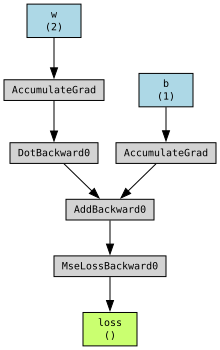

In [191]:
params = {
    "w": w,
    "b": b,
    "z0": z0,
    "loss":loss
    #"p1": p1
}

render_graph(loss, params, filename="logistic_graph")

In [192]:
def explore_clean(fn, depth=0):
    if fn is None:
        return
    name = fn.__class__.__name__
    print("  " * depth + name)
    if hasattr(fn, 'next_functions'):
        for next_fn, _ in fn.next_functions:
            explore_clean(next_fn, depth + 1)

explore_clean(loss.grad_fn)

MseLossBackward0
  AddBackward0
    DotBackward0
      AccumulateGrad
    AccumulateGrad


In [193]:
class Value:
    """ stores a single scalar value and its gradient """

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0
        # internal variables used for autograd graph construction
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op # the op that produced this node, for graphviz / debugging / etc

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
            print(" add backward ", self.grad, other.grad, out )
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
            print(" mul backward ", self.grad, other.grad, out )
        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        
        def _backward():
          self.grad += out.data * out.grad # NOTE: in the video I incorrectly used = instead of +=. Fixed here.
          print(" exp backward ", self.grad, out )
        out._backward = _backward
        
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
            print(" pow backward ", self.grad, out )
        out._backward = _backward

        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out

    # sigmoid activation function
    def sigmoid(self):
        x = self.data
        t = 1/(1+(math.exp(-x)))
        out = Value(t, (self, ), 'sigmoid')
        
        def _backward():
            f = 1/(1+(math.exp(-x)))
            self.grad += (f*(1 - f)) * out.grad
            print(" sigmoid backward ", f, self.grad, out )
        out._backward = _backward
        return out

    
    def log(self):
        # natural logarithm ln(x)
        if self.data <= 0:
            raise ValueError("log(x) requires x > 0")
    
        out = Value(math.log(self.data), (self,), 'log')
    
        def _backward():
            # d/dx log(x) = 1/x
            self.grad += (1.0 / self.data) * out.grad
            print(" log backward ", self.grad, out )
    
        out._backward = _backward
        return out
    
    def backward(self):

        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                print( "v ", v)
                visited.add(v)
                for child in v._prev:
                    print( "child ", child)
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1
        for v in reversed(topo):
            v._backward()

    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

In [194]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ data %.4f | grad %.4f }" % (n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [195]:
# setup
LR = 0.05

x00 = Value(1.0, label='x00')
x01 = Value(1.1, label='x01')

w0 = Value(0.1, label='w0')
w1 = Value(0.1, label='w1')
b  = Value(0.1, label='b')

y = Value(1.0, label='target')


v  Value(data=0.4760999999999999, grad=0)
child  Value(data=-0.69, grad=0)
v  Value(data=-0.69, grad=0)
child  Value(data=-1.0, grad=0)
v  Value(data=-1.0, grad=0)
child  Value(data=1.0, grad=0)
v  Value(data=1.0, grad=0)
child  Value(data=-1, grad=0)
v  Value(data=-1, grad=0)
child  Value(data=0.31000000000000005, grad=0)
v  Value(data=0.31000000000000005, grad=0)
child  Value(data=0.21000000000000002, grad=0)
v  Value(data=0.21000000000000002, grad=0)
child  Value(data=0.1, grad=0)
v  Value(data=0.1, grad=0)
child  Value(data=1.0, grad=0)
v  Value(data=1.0, grad=0)
child  Value(data=0.1, grad=0)
v  Value(data=0.1, grad=0)
child  Value(data=0.11000000000000001, grad=0)
v  Value(data=0.11000000000000001, grad=0)
child  Value(data=0.1, grad=0)
v  Value(data=0.1, grad=0)
child  Value(data=1.1, grad=0)
v  Value(data=1.1, grad=0)
child  Value(data=0.1, grad=0)
v  Value(data=0.1, grad=0)
 pow backward  -1.38 Value(data=0.4760999999999999, grad=1)
 add backward  -1.38 -1.38 Value(data=-0.69,

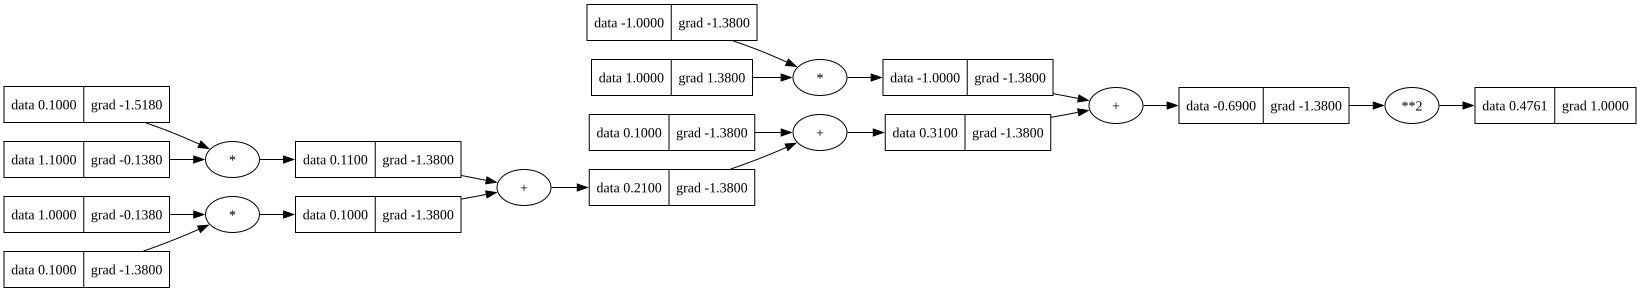

In [196]:
# forwad pass
x00w0 = x00 * w0; x00w0.label = 'x00*w0'
x01w1 = x01 * w1; x01w1.label = 'x01*w1'

z0 = x00w0 + x01w1; z0.label = 'x00*w0 + x01*w1'
z0 = z0 + b; z0.label = 'z0'

loss = (z0 - y) ** 2

# backward
loss.backward()

# update grads
w0 -= LR * w0.grad
w1 -= LR * w1.grad
b -= LR * b.grad

draw_dot(loss)